# LangChain Complete Guide
## RAG | Agents | LangGraph | LangSmith

This notebook covers:
1. RAG Without LangChain (manual implementation)
2. RAG With LangChain (interactive component visualization)
3. LangGraph Agent with Weather Tool, Guardrails, and Orchestrator
4. LangSmith Tracing

Model used throughout: `gpt-4o-mini`

---
## SECTION 0 - Installation and Setup

In [1]:
import subprocess, sys

packages = [
    "openai",
    "langchain",
    "langchain-openai",
    "langchain-community",
    "langchain-core",
    "langgraph",
    "langsmith",
    "faiss-cpu",
    "tiktoken",
    "numpy",
    "requests",
    "python-dotenv",
    "chromadb"
]

print("📦 Installing dependencies...")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + packages,
    check=True
)

print("✅ All dependencies installed successfully")

📦 Installing dependencies...
✅ All dependencies installed successfully


In [ ]:
import os

# Set your API keys here directly or via environment
# Replace the placeholder strings with your actual keys

os.environ["OPENAI_API_KEY"] = ""          # <-- replace with your OpenAI key
os.environ["LANGCHAIN_API_KEY"] = ""      # <-- replace with your LangSmith key
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-complete-guide"

# Optional: weather API key for real weather data (we will mock if not set)
os.environ["OPENWEATHER_API_KEY"] = ""             # <-- optional, leave blank to use mock

print("[SETUP] Environment variables configured.")
print(f"[SETUP] OpenAI key set: {'Yes' if os.environ.get('OPENAI_API_KEY', '').startswith('sk-') else 'No - please update'}")
print(f"[SETUP] LangSmith key set: {'Yes' if os.environ.get('LANGCHAIN_API_KEY', '').startswith('lsv2') else 'No - tracing will be disabled'}")

[SETUP] Environment variables configured.
[SETUP] OpenAI key set: Yes
[SETUP] LangSmith key set: Yes


In [3]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)  # won't overwrite an already-set env var

api_key = os.getenv('OPENAI_API_KEY')
if api_key:
    print(f'✅ API key loaded: sk-...{api_key[-4:]}')
else:
    print('⚠️  OPENAI_API_KEY not found.')
    print('   Create a .env file in this folder with: OPENAI_API_KEY=sk-...')

from openai import OpenAI
client = OpenAI()  # automatically reads OPENAI_API_KEY from environment
print('\n✅ OpenAI client initialized')


✅ API key loaded: sk-...uaEA

✅ OpenAI client initialized


---
## SECTION 1 - RAG Without LangChain

We build every component manually:
- Chunking
- Embedding
- Vector store (in-memory, using cosine similarity)
- Retrieval
- Generation

In [4]:
# ---------------------------------------------------------------
# COMPONENT 1: Document (raw text we want to query against)
# ---------------------------------------------------------------

RAW_DOCUMENT = """
LangChain is a framework designed to simplify the creation of applications using large language models (LLMs).
It provides tools for chaining prompts, managing memory, integrating with external data sources, and building agents.

LangGraph is a library built on top of LangChain that enables building stateful, multi-actor applications with LLMs.
It uses a graph-based architecture where nodes represent computation steps and edges represent transitions.
LangGraph is particularly useful for building complex agent workflows that require cycles and branching logic.

LangSmith is a developer platform for debugging, testing, evaluating, and monitoring LLM applications.
It provides tracing capabilities that allow developers to see every step of an LLM chain or agent run.
LangSmith integrates seamlessly with LangChain and LangGraph.

RAG stands for Retrieval-Augmented Generation. It is a technique where relevant documents are retrieved
from a knowledge base and provided to the LLM as context before generating a response.
RAG helps reduce hallucinations and allows the model to answer questions about private or recent data.

Embeddings are numerical vector representations of text. Similar texts produce similar embedding vectors.
This property allows us to find semantically similar documents using distance metrics like cosine similarity.
OpenAI's text-embedding-ada-002 and text-embedding-3-small are commonly used embedding models.

Vector stores are databases optimized for storing and searching embedding vectors.
FAISS (Facebook AI Similarity Search) is a popular open-source vector store for fast nearest-neighbor search.
Other vector stores include Chroma, Pinecone, Weaviate, and Qdrant.

Agents are LLM-powered systems that can use tools to accomplish tasks.
A tool is a function that the agent can call, such as a web search, calculator, or API call.
Agents decide which tools to use and in what order based on the user's query.
"""

print("[RAW DOCUMENT LOADED]")
print(f"Total characters: {len(RAW_DOCUMENT)}")
print(f"Total words: {len(RAW_DOCUMENT.split())}")

[RAW DOCUMENT LOADED]
Total characters: 1948
Total words: 278


In [7]:
from langchain_community.document_loaders import PyPDFLoader

# Load RAW_DOCUMENT from a PDF file (overwrites current RAW_DOCUMENT)

pdf_path = "BU_HR_Manual_.pdf"  # update this path


loader = PyPDFLoader(pdf_path)
pdf_docs = loader.load()

RAW_DOCUMENT = "\n\n".join(doc.page_content.strip() for doc in pdf_docs if doc.page_content.strip())

print(f"[PDF LOAD] Loaded {len(pdf_docs)} pages from: {pdf_path}")
print(f"[PDF LOAD] RAW_DOCUMENT chars: {len(RAW_DOCUMENT)}")
print(f"[PDF LOAD] RAW_DOCUMENT words: {len(RAW_DOCUMENT.split())}")
print("\n[PDF LOAD] Preview:\n")
print(RAW_DOCUMENT[:800])

[PDF LOAD] Loaded 93 pages from: BU_HR_Manual_.pdf
[PDF LOAD] RAW_DOCUMENT chars: 161776
[PDF LOAD] RAW_DOCUMENT words: 24206

[PDF LOAD] Preview:

MANUAL OF HUMAN RESOURCES (HR) 
POLICIES AND PROCESSES 
 
 
 
 
 
 
 
 
 
BENNETT UNIVERSITY 
GREATER NOIDA

MANUAL OF HUMAN RESOURCES POLICIES AND PROCESSES, BENNETT UNIVERSITY           P a g e  2 | 93 
 
INDEX 
SR.NO. CHAPTERS PAGE NO. 
1 INTRODUCTION 03-05 
2 RECRUITMENT POLICY 06-35 
3 CODE OF CONDUCT AND ETHICS 36-43 
4 LEAVE RULES 44-57 
5 PERFORMANCE APPRAISAL SYSTEM 58-72 
6 PROMOTION POLICY (TEACHING- NON-TEACHING) 73-77 
7 ON-CAMPUS ACCOMMODATION POLICY 78-83 
8 CRECHE POLICY 84-86 
9 POLICY ON RELOCATION REIMBURSEMENTS 87-88 
10 SEPARATION POLICY 89-92

MANUAL OF HUMAN RESOURCES POLICIES AND PROCESSES, BENNETT UNIVERSITY           P a g e  3 | 93 
 
1.    INTRODUCTION 
 
This HR manual serves as a comprehensive guide for all employees within our organization. It 
outlines the p


In [8]:
# ---------------------------------------------------------------
# COMPONENT 2: Chunking
# Split the document into overlapping chunks
# ---------------------------------------------------------------

def chunk_text(text: str, chunk_size: int = 200, overlap: int = 40) -> list:
    """
    Split text into overlapping character-level chunks.

    Args:
        text: The raw text to chunk.
        chunk_size: Max characters per chunk.
        overlap: Characters shared between consecutive chunks.

    Returns:
        List of chunk strings.
    """
    # Strip leading/trailing whitespace from paragraphs first
    paragraphs = [p.strip() for p in text.strip().split("\n\n") if p.strip()]

    chunks = []
    for para in paragraphs:
        start = 0
        while start < len(para):
            end = start + chunk_size
            chunk = para[start:end].strip()
            if chunk:
                chunks.append(chunk)
            start += chunk_size - overlap

    return chunks


chunks = chunk_text(RAW_DOCUMENT, chunk_size=250, overlap=50)

print(f"[CHUNKING] Produced {len(chunks)} chunks\n")
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} (len={len(chunk)}) ---")
    print(chunk)
    print()

[CHUNKING] Produced 852 chunks

--- Chunk 1 (len=107) ---
MANUAL OF HUMAN RESOURCES (HR) 
POLICIES AND PROCESSES 
 
 
 
 
 
 
 
 
 
BENNETT UNIVERSITY 
GREATER NOIDA

--- Chunk 2 (len=250) ---
MANUAL OF HUMAN RESOURCES POLICIES AND PROCESSES, BENNETT UNIVERSITY           P a g e  2 | 93 
 
INDEX 
SR.NO. CHAPTERS PAGE NO. 
1 INTRODUCTION 03-05 
2 RECRUITMENT POLICY 06-35 
3 CODE OF CONDUCT AND ETHICS 36-43 
4 LEAVE RULES 44-57 
5 PERFORMANC

--- Chunk 3 (len=250) ---
ND ETHICS 36-43 
4 LEAVE RULES 44-57 
5 PERFORMANCE APPRAISAL SYSTEM 58-72 
6 PROMOTION POLICY (TEACHING- NON-TEACHING) 73-77 
7 ON-CAMPUS ACCOMMODATION POLICY 78-83 
8 CRECHE POLICY 84-86 
9 POLICY ON RELOCATION REIMBURSEMENTS 87-88 
10 SEPARATION P

--- Chunk 4 (len=61) ---
N RELOCATION REIMBURSEMENTS 87-88 
10 SEPARATION POLICY 89-92

--- Chunk 5 (len=250) ---
MANUAL OF HUMAN RESOURCES POLICIES AND PROCESSES, BENNETT UNIVERSITY           P a g e  3 | 93 
 
1.    INTRODUCTION 
 
This HR manual serves as a comprehensive gu

In [9]:
# ---------------------------------------------------------------
# COMPONENT 3: Embeddings
# Use OpenAI embeddings API directly (no LangChain)
# ---------------------------------------------------------------
import os
from openai import OpenAI
import numpy as np

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])


def get_embeddings(texts: list, model: str = "text-embedding-3-small") -> list:
    """
    Call OpenAI Embeddings API and return list of float vectors.
    """
    print(f"[EMBEDDINGS] Requesting embeddings for {len(texts)} texts using model: {model}")
    response = client.embeddings.create(input=texts, model=model)
    vectors = [item.embedding for item in response.data]
    print(f"[EMBEDDINGS] Received {len(vectors)} vectors, each of dimension {len(vectors[0])}")
    return vectors


# Embed all chunks
chunk_embeddings = get_embeddings(chunks)

# Show a preview of the first embedding
print(f"\n[EMBEDDINGS] Preview of Chunk 1 embedding (first 8 dimensions):")
print(np.round(chunk_embeddings[0][:8], 5))

[EMBEDDINGS] Requesting embeddings for 852 texts using model: text-embedding-3-small
[EMBEDDINGS] Received 852 vectors, each of dimension 1536

[EMBEDDINGS] Preview of Chunk 1 embedding (first 8 dimensions):
[-0.01819  0.03885  0.07446  0.00841 -0.03073 -0.02246  0.02069  0.01747]


In [10]:
# ---------------------------------------------------------------
# COMPONENT 4: In-Memory Vector Store
# Store chunks + embeddings, support cosine similarity search
# ---------------------------------------------------------------

class SimpleVectorStore:
    """
    Minimal in-memory vector store using cosine similarity.
    No external libraries required beyond numpy.
    """

    def __init__(self):
        self.texts = []
        self.embeddings = []  # list of numpy arrays

    def add(self, texts: list, embeddings: list):
        self.texts.extend(texts)
        self.embeddings.extend([np.array(e) for e in embeddings])
        print(f"[VECTOR STORE] Added {len(texts)} documents. Total: {len(self.texts)}")

    @staticmethod
    def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
        return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

    def search(self, query_embedding: list, top_k: int = 3) -> list:
        """
        Return top_k most similar chunks and their similarity scores.
        """
        q = np.array(query_embedding)
        scores = [(self.cosine_similarity(q, e), t) for e, t in zip(self.embeddings, self.texts)]
        scores.sort(key=lambda x: x[0], reverse=True)
        return scores[:top_k]


# Build the store
vector_store = SimpleVectorStore()
vector_store.add(chunks, chunk_embeddings)
print(f"[VECTOR STORE] Ready. Holding {len(vector_store.texts)} chunks.")

[VECTOR STORE] Added 852 documents. Total: 852
[VECTOR STORE] Ready. Holding 852 chunks.


In [11]:
# ---------------------------------------------------------------
# COMPONENT 5: Retrieval + Generation (Full RAG Pipeline)
# ---------------------------------------------------------------

def rag_query_no_langchain(question: str, top_k: int = 3) -> str:
    """
    Full RAG pipeline without any LangChain dependency.
    Steps:
      1. Embed the question
      2. Retrieve top_k similar chunks
      3. Build a prompt with retrieved context
      4. Call GPT-4o-mini to generate the answer
    """
    print(f"\n{'='*60}")
    print(f"[RAG QUERY] Question: {question}")
    print(f"{'='*60}")

    # Step 1: Embed the query
    print("\n[STEP 1] Embedding the question...")
    query_embedding = get_embeddings([question])[0]

    # Step 2: Retrieve
    print(f"\n[STEP 2] Retrieving top {top_k} chunks from vector store...")
    results = vector_store.search(query_embedding, top_k=top_k)
    for rank, (score, text) in enumerate(results, 1):
        print(f"  Rank {rank} | Similarity: {score:.4f}")
        print(f"  Text: {text[:120]}...")
        print()

    # Step 3: Build context
    context = "\n\n".join([text for _, text in results])
    prompt = f"""You are a helpful assistant. Use ONLY the context below to answer the question.
If the context does not contain the answer, say "I don't know based on the provided context."

Context:
{context}

Question: {question}

Answer:"""

    print(f"[STEP 3] Prompt built. Context length: {len(context)} chars.")

    # Step 4: Generate
    print("\n[STEP 4] Calling GPT-4o-mini for answer generation...")
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a concise and accurate assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    answer = response.choices[0].message.content
    print(f"\n[ANSWER]\n{answer}")
    return answer


# Test it
answer1 = rag_query_no_langchain("What is RAG and why is it useful?")


[RAG QUERY] Question: What is RAG and why is it useful?

[STEP 1] Embedding the question...
[EMBEDDINGS] Requesting embeddings for 1 texts using model: text-embedding-3-small
[EMBEDDINGS] Received 1 vectors, each of dimension 1536

[STEP 2] Retrieving top 3 chunks from vector store...
  Rank 1 | Similarity: 0.2842
  Text: ganizing academic, research, industrial 
and/or professional  activities; and v) Capacity to undertake/ lead sponsored R...

  Rank 2 | Similarity: 0.2569
  Text: rch laboratories, or any other University, in India and abroad; and 
(d) Any other purpose for the academic development ...

  Rank 3 | Similarity: 0.2558
  Text: s 
Amount 
Sanctioned 
Chief or Co 
Investigator 
Specify 
1      
2      
3      
Self-Assessed 
API Score 
 HOD Remark...

[STEP 3] Prompt built. Context length: 583 chars.

[STEP 4] Calling GPT-4o-mini for answer generation...

[ANSWER]
I don't know based on the provided context.


In [12]:
# Test with another question
answer2 = rag_query_no_langchain("What is LangGraph and how does it differ from LangChain?")


[RAG QUERY] Question: What is LangGraph and how does it differ from LangChain?

[STEP 1] Embedding the question...
[EMBEDDINGS] Requesting embeddings for 1 texts using model: text-embedding-3-small
[EMBEDDINGS] Received 1 vectors, each of dimension 1536

[STEP 2] Retrieving top 3 chunks from vector store...
  Rank 1 | Similarity: 0.2049
  Text: Does the goal 
measure actual 
outputs /results, 
not just activities? 
 
Has a 
reasonable 
timeframe 
been 
identified...

  Rank 2 | Similarity: 0.2034
  Text: UND 
Does the 
goal focus 
on a 
specific 
area? 
 
Can progress be 
measured for the goal? 
 
Is the goal a 
"stretch",...

  Rank 3 | Similarity: 0.1975
  Text: nographs etc. can also 
be included here)...

[STEP 3] Prompt built. Context length: 542 chars.

[STEP 4] Calling GPT-4o-mini for answer generation...

[ANSWER]
I don't know based on the provided context.


---
## SECTION 2 - RAG With LangChain

Same pipeline but using LangChain components. We log each component explicitly so the internals are visible.

In [16]:
# ---------------------------------------------------------------
# COMPONENT 1: Document Loading and Chunking with LangChain
# ---------------------------------------------------------------

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
# Wrap raw text in a LangChain Document object
raw_doc = Document(page_content=RAW_DOCUMENT, metadata={"source": "manual", "title": "LangChain Overview"})

print("[DOCUMENT LOADING]")
print(f"Document metadata: {raw_doc.metadata}")
print(f"Content length: {len(raw_doc.page_content)} chars")

# LangChain text splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=250,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

lc_chunks = splitter.split_documents([raw_doc])

print(f"\n[CHUNKING] RecursiveCharacterTextSplitter produced {len(lc_chunks)} chunks")
for i, chunk in enumerate(lc_chunks):
    print(f"--- Chunk {i+1} (len={len(chunk.page_content)}) ---")
    print(chunk.page_content)
    print(f"Metadata: {chunk.metadata}")
    print()

[DOCUMENT LOADING]
Document metadata: {'source': 'manual', 'title': 'LangChain Overview'}
Content length: 161776 chars

[CHUNKING] RecursiveCharacterTextSplitter produced 830 chunks
--- Chunk 1 (len=107) ---
MANUAL OF HUMAN RESOURCES (HR) 
POLICIES AND PROCESSES 
 
 
 
 
 
 
 
 
 
BENNETT UNIVERSITY 
GREATER NOIDA
Metadata: {'source': 'manual', 'title': 'LangChain Overview'}

--- Chunk 2 (len=236) ---
MANUAL OF HUMAN RESOURCES POLICIES AND PROCESSES, BENNETT UNIVERSITY           P a g e  2 | 93 
 
INDEX 
SR.NO. CHAPTERS PAGE NO. 
1 INTRODUCTION 03-05 
2 RECRUITMENT POLICY 06-35 
3 CODE OF CONDUCT AND ETHICS 36-43 
4 LEAVE RULES 44-57
Metadata: {'source': 'manual', 'title': 'LangChain Overview'}

--- Chunk 3 (len=244) ---
4 LEAVE RULES 44-57 
5 PERFORMANCE APPRAISAL SYSTEM 58-72 
6 PROMOTION POLICY (TEACHING- NON-TEACHING) 73-77 
7 ON-CAMPUS ACCOMMODATION POLICY 78-83 
8 CRECHE POLICY 84-86 
9 POLICY ON RELOCATION REIMBURSEMENTS 87-88 
10 SEPARATION POLICY 89-92
Metadata: {'source': 'ma

In [17]:
# ---------------------------------------------------------------
# COMPONENT 2: Embeddings with LangChain
# ---------------------------------------------------------------

import os
from langchain_openai import OpenAIEmbeddings

print("[EMBEDDINGS] Initializing LangChain OpenAIEmbeddings...")
embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=os.environ["OPENAI_API_KEY"]
)

# Embed a single test text to show the vector
test_text = "What is retrieval augmented generation?"
test_vector = embeddings_model.embed_query(test_text)

print(f"[EMBEDDINGS] Model: text-embedding-3-small")
print(f"[EMBEDDINGS] Embedding dimension: {len(test_vector)}")
print(f"[EMBEDDINGS] Query: '{test_text}'")
print(f"[EMBEDDINGS] First 8 dimensions: {[round(v, 5) for v in test_vector[:8]]}")

[EMBEDDINGS] Initializing LangChain OpenAIEmbeddings...
[EMBEDDINGS] Model: text-embedding-3-small
[EMBEDDINGS] Embedding dimension: 1536
[EMBEDDINGS] Query: 'What is retrieval augmented generation?'
[EMBEDDINGS] First 8 dimensions: [0.02075, -0.00277, 0.04279, 0.0164, -0.02721, -0.03091, 0.02675, 0.02124]


In [18]:
import subprocess, sys

print("📦 Installing ChromaDB...")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "chromadb"],
    check=True
)

print("✅ ChromaDB installed successfully")

📦 Installing ChromaDB...
✅ ChromaDB installed successfully


In [19]:
# ---------------------------------------------------------------
# COMPONENT 3: Vector Store with ChromaDB
# ---------------------------------------------------------------

from langchain_community.vectorstores import Chroma

print("[VECTOR STORE] Building Chroma vector store from chunks...")

chroma_store = Chroma.from_documents(
    documents=lc_chunks,
    embedding=embeddings_model,
    persist_directory="./chroma_db"  # optional (for saving DB)
)

print("[VECTOR STORE] Chroma DB created.")
print(f"[VECTOR STORE] Number of indexed documents: {len(lc_chunks)}")

# Test similarity search directly
print("\n[VECTOR STORE] Test similarity search for 'vector stores and FAISS':")

test_results = chroma_store.similarity_search_with_score(
    "vector stores and FAISS",
    k=3
)

for rank, (doc, score) in enumerate(test_results, 1):
    print(f"  Rank {rank} | Score: {score:.4f}")
    print(f"  Text: {doc.page_content[:100]}...")
    print()

# Persistence is automatic in ChromaDB 0.4.x+

[VECTOR STORE] Building Chroma vector store from chunks...
[VECTOR STORE] Chroma DB created.
[VECTOR STORE] Number of indexed documents: 830

[VECTOR STORE] Test similarity search for 'vector stores and FAISS':
  Rank 1 | Score: 1.4308
  Text: financial data. With the implementation of a corporate database, it is ho ped that more of the 
proc...

  Rank 2 | Score: 1.4334
  Text: with   superior knowledge of computerized library service....

  Rank 3 | Score: 1.4339
  Text: not a guaranteed entitlement but rather a temporary arrangement contingent upon inventory 
availabil...



In [20]:
# ---------------------------------------------------------------
# COMPONENT 4: Retriever
# ---------------------------------------------------------------

retriever = chroma_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

print("[RETRIEVER] Created Chroma retriever.")
print(f"[RETRIEVER] Search type: similarity | Top-k: 3")

# Test retriever
test_query = "How do agents use tools?"
retrieved_docs = retriever.invoke(test_query)
print(f"\n[RETRIEVER] Test query: '{test_query}'")
print(f"[RETRIEVER] Retrieved {len(retrieved_docs)} documents:")
for i, doc in enumerate(retrieved_docs, 1):
    print(f"  Doc {i}: {doc.page_content[:120]}...")

[RETRIEVER] Created Chroma retriever.
[RETRIEVER] Search type: similarity | Top-k: 3

[RETRIEVER] Test query: 'How do agents use tools?'
[RETRIEVER] Retrieved 3 documents:
  Doc 1: (ii) Demonstrative Performance 
S. No. Attributes  
1 Foresight and Planning  
2 Job Knowledge and skills  
3 
Applicati...
  Doc 2: equipment, software, telephone, Internet and other technological assets and services provided by 
the organization for o...
  Doc 3: verb? (To/ 
in order to 
+verb)? 
Is the:  
numeric/quantitative? 
Or 
descriptive/qualitative? 
or Financial? 
Is the g...


In [22]:
# ---------------------------------------------------------------
# COMPONENT 5: Prompt Template + LLM + RAG Chain
# ---------------------------------------------------------------

import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
# LLM
print("[LLM] Initializing ChatOpenAI with gpt-4o-mini...")
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    openai_api_key=os.environ["OPENAI_API_KEY"]
)

# Prompt template
rag_prompt = ChatPromptTemplate.from_template("""
You are a helpful assistant. Answer the question using ONLY the provided context.
If the context does not contain the answer, respond with: "I don't know based on the provided context."

Context:
{context}

Question: {question}

Answer:
""")

print("[PROMPT] RAG prompt template created.")

# Helper to format retrieved documents
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])

# Build the chain using LCEL (LangChain Expression Language)
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print("[CHAIN] RAG chain assembled using LCEL:")
print("  Retriever -> format_docs -> Prompt -> LLM -> StrOutputParser")

[LLM] Initializing ChatOpenAI with gpt-4o-mini...
[PROMPT] RAG prompt template created.
[CHAIN] RAG chain assembled using LCEL:
  Retriever -> format_docs -> Prompt -> LLM -> StrOutputParser


In [23]:
# ---------------------------------------------------------------
# Run RAG Queries with LangChain
# ---------------------------------------------------------------

def rag_query_langchain(question: str):
    print(f"\n{'='*60}")
    print(f"[RAG QUERY - LangChain] {question}")
    print(f"{'='*60}")

    # Show what is retrieved before the LLM sees it
    print("\n[RETRIEVAL LOG] Fetching relevant chunks...")
    retrieved = retriever.invoke(question)
    for i, doc in enumerate(retrieved, 1):
        print(f"  Chunk {i}: {doc.page_content[:120]}...")

    print("\n[LLM] Generating answer...")
    answer = rag_chain.invoke(question)
    print(f"\n[ANSWER]\n{answer}")
    return answer


# Run queries
rag_query_langchain("What is LangSmith used for?")


[RAG QUERY - LangChain] What is LangSmith used for?

[RETRIEVAL LOG] Fetching relevant chunks...
  Chunk 1: Date & 
Status 
Amount 
Sanctioned 
Chief or Co 
Investigator 
Specify 
1      
2      
3      
Self-Assessed 
API Score...
  Chunk 2: MANUAL OF HUMAN RESOURCES POLICIES AND PROCESSES, BENNETT UNIVERSITY           P a g e  59 | 93 
5.4.4 WHAT DOES SMAART ...
  Chunk 3: Type of 
Journal (N - 
National, I -
International) 
Name of 
the Journal 
Publisher  
SCIMago 
ranking 
of 
Journal 
Ra...

[LLM] Generating answer...

[ANSWER]
I don't know based on the provided context.


"I don't know based on the provided context."

In [24]:
rag_query_langchain("What is IIMA")


[RAG QUERY - LangChain] What is IIMA

[RETRIEVAL LOG] Fetching relevant chunks...
  Chunk 1: skills. 
 
2.6.3    ASSOCIATE PROFESSOR 
 
❖ Minimum Qualification- Ph.D. in concerned/ Allied/ relevant disciples. Fell...
  Chunk 2: Institute   with excellent academic record (For Accountants). 
(iii) Knowledge of computer applications viz. word proces...
  Chunk 3: (ii) INTERNAL JOB POSTING (IJP): 
 
To foster employee growth and succession planning, we utilize Internal Job Postings ...

[LLM] Generating answer...

[ANSWER]
I don't know based on the provided context.


"I don't know based on the provided context."

---
## SECTION 3 - LangGraph Agent

We build a stateful agent using LangGraph with:
- Weather tool
- Calculator tool
- Wikipedia summary tool
- Input guardrail
- Orchestrator agent that routes between specialized agents

In [25]:
# ---------------------------------------------------------------
# TOOL DEFINITIONS
# ---------------------------------------------------------------

import math
import json
import requests
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """
    Get the current weather for a city.
    Returns temperature (Celsius), condition, and humidity.
    """
    print(f"[TOOL: get_weather] Called with city='{city}'")

    api_key = os.environ.get("OPENWEATHER_API_KEY", "")

    if api_key:
        url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
        try:
            resp = requests.get(url, timeout=5)
            data = resp.json()
            if resp.status_code == 200:
                temp = data["main"]["temp"]
                condition = data["weather"][0]["description"]
                humidity = data["main"]["humidity"]
                result = f"Weather in {city}: {temp}C, {condition}, humidity {humidity}%"
                print(f"[TOOL: get_weather] Result: {result}")
                return result
        except Exception as e:
            print(f"[TOOL: get_weather] API call failed: {e}. Using mock data.")

    # Mock data when no API key is available
    mock_data = {
        "london": "Weather in London: 12C, overcast clouds, humidity 78%",
        "new york": "Weather in New York: 18C, clear sky, humidity 55%",
        "tokyo": "Weather in Tokyo: 22C, light rain, humidity 82%",
        "paris": "Weather in Paris: 15C, partly cloudy, humidity 65%",
        "hyderabad": "Weather in Hyderabad: 35C, sunny, humidity 40%",
    }
    result = mock_data.get(city.lower(), f"Weather in {city}: 20C, clear sky, humidity 60% (mock)")
    print(f"[TOOL: get_weather] Mock result: {result}")
    return result


@tool
def calculator(expression: str) -> str:
    """
    Evaluate a mathematical expression safely.
    Examples: '2 + 2', 'sqrt(16)', '100 * 1.08'
    """
    print(f"[TOOL: calculator] Expression: '{expression}'")
    try:
        # Safe evaluation using math functions only
        allowed_names = {k: v for k, v in math.__dict__.items() if not k.startswith("_")}
        allowed_names["abs"] = abs
        result = eval(expression, {"__builtins__": {}}, allowed_names)
        output = f"Result of '{expression}' = {result}"
        print(f"[TOOL: calculator] {output}")
        return output
    except Exception as e:
        error = f"Could not evaluate '{expression}': {str(e)}"
        print(f"[TOOL: calculator] ERROR: {error}")
        return error


@tool
def get_definition(term: str) -> str:
    """
    Return a short definition or explanation of a technical term.
    """
    print(f"[TOOL: get_definition] Term: '{term}'")
    definitions = {
        "rag": "RAG (Retrieval-Augmented Generation) is a technique that combines document retrieval with LLM generation to answer questions using external knowledge.",
        "langchain": "LangChain is a Python/TypeScript framework for building LLM-powered applications with chains, agents, and memory.",
        "langgraph": "LangGraph is a LangChain extension for building stateful multi-actor workflows using a directed graph structure.",
        "embedding": "An embedding is a high-dimensional numerical vector representing the semantic meaning of a piece of text.",
        "faiss": "FAISS (Facebook AI Similarity Search) is an open-source library for efficient similarity search over dense vectors.",
        "agent": "An agent is an LLM-powered system that can choose and call tools autonomously to complete a task.",
        "vector store": "A vector store is a database optimized for storing and retrieving high-dimensional embedding vectors using similarity search.",
    }
    key = term.lower().strip()
    result = definitions.get(key, f"No definition found for '{term}'. Try: rag, langchain, langgraph, embedding, faiss, agent, vector store")
    print(f"[TOOL: get_definition] Result: {result[:80]}...")
    return result


print("[TOOLS] Defined tools:")
print("  - get_weather: Get current weather for a city")
print("  - calculator: Evaluate a math expression")
print("  - get_definition: Get definition of a technical term")

[TOOLS] Defined tools:
  - get_weather: Get current weather for a city
  - calculator: Evaluate a math expression
  - get_definition: Get definition of a technical term


In [26]:
# ---------------------------------------------------------------
# GUARDRAIL - Input Validation
# Block harmful or off-topic queries before the agent runs
# ---------------------------------------------------------------

BLOCKED_KEYWORDS = [
    "bomb", "weapon", "hack", "exploit", "malware", "virus",
    "illegal", "drugs", "nsfw"
]

def guardrail_check(user_input: str) -> tuple:
    """
    Returns (is_safe: bool, reason: str).
    Blocks overly short inputs and known harmful keywords.
    """
    print(f"[GUARDRAIL] Checking input: '{user_input[:80]}'")

    if len(user_input.strip()) < 3:
        print("[GUARDRAIL] BLOCKED - Input too short.")
        return False, "Input is too short. Please provide a meaningful question."

    lower_input = user_input.lower()
    for keyword in BLOCKED_KEYWORDS:
        if keyword in lower_input:
            print(f"[GUARDRAIL] BLOCKED - Harmful keyword detected: '{keyword}'")
            return False, f"Input contains disallowed content: '{keyword}'. This agent cannot assist with such requests."

    print("[GUARDRAIL] PASSED - Input is safe.")
    return True, "OK"


# Test guardrail
print("\n--- Guardrail Tests ---")
print(guardrail_check("What is the weather in London?"))
print(guardrail_check("hi"))
print(guardrail_check("How do I hack a website?"))


--- Guardrail Tests ---
[GUARDRAIL] Checking input: 'What is the weather in London?'
[GUARDRAIL] PASSED - Input is safe.
(True, 'OK')
[GUARDRAIL] Checking input: 'hi'
[GUARDRAIL] BLOCKED - Input too short.
(False, 'Input is too short. Please provide a meaningful question.')
[GUARDRAIL] Checking input: 'How do I hack a website?'
[GUARDRAIL] BLOCKED - Harmful keyword detected: 'hack'
(False, "Input contains disallowed content: 'hack'. This agent cannot assist with such requests.")


In [27]:
# ---------------------------------------------------------------
# LANGGRAPH AGENT
# ---------------------------------------------------------------

from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.messages import SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
import operator

# Bind tools to the LLM
tools = [get_weather, calculator, get_definition]

agent_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    openai_api_key=os.environ["OPENAI_API_KEY"]
).bind_tools(tools)

print("[AGENT] ChatOpenAI with gpt-4o-mini initialized and tools bound.")
print(f"[AGENT] Tools available: {[t.name for t in tools]}")


# --- State definition ---
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]


# --- Node: call the LLM ---
def call_llm(state: AgentState) -> AgentState:
    print("\n[NODE: call_llm] Invoking LLM...")
    messages = state["messages"]
    print(f"[NODE: call_llm] Messages in state: {len(messages)}")

    # Prepend system message
    system = SystemMessage(content=(
        "You are a helpful assistant with access to weather, calculator, and definition tools. "
        "Use tools when needed to answer the user's question accurately."
    ))
    response = agent_llm.invoke([system] + messages)

    print(f"[NODE: call_llm] Response type: {type(response).__name__}")
    if response.tool_calls:
        print(f"[NODE: call_llm] Tool calls requested: {[tc['name'] for tc in response.tool_calls]}")
    else:
        print(f"[NODE: call_llm] No tool calls. Final answer: {response.content[:80]}...")

    return {"messages": [response]}


# --- Routing function ---
def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print(f"[ROUTER] Tool calls detected -> routing to 'tools' node")
        return "tools"
    print(f"[ROUTER] No tool calls -> routing to END")
    return END


# --- Build the graph ---
tool_node = ToolNode(tools)

workflow = StateGraph(AgentState)
workflow.add_node("llm", call_llm)
workflow.add_node("tools", tool_node)
workflow.set_entry_point("llm")
workflow.add_conditional_edges("llm", should_continue)
workflow.add_edge("tools", "llm")  # After tool execution, go back to LLM

agent_app = workflow.compile()

print("\n[LANGGRAPH] Agent graph compiled successfully.")
print("[LANGGRAPH] Graph structure:")
print("  Entry -> llm -> (if tool calls) -> tools -> llm -> ... -> END")

[AGENT] ChatOpenAI with gpt-4o-mini initialized and tools bound.
[AGENT] Tools available: ['get_weather', 'calculator', 'get_definition']

[LANGGRAPH] Agent graph compiled successfully.
[LANGGRAPH] Graph structure:
  Entry -> llm -> (if tool calls) -> tools -> llm -> ... -> END


### LangGraph Agent (llm ↔ tools)

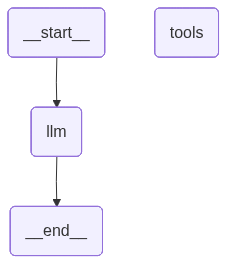

In [28]:
from IPython.display import Image, display, Markdown

def show_langgraph(app, title: str):
    display(Markdown(f"### {title}"))
    graph = app.get_graph()
    try:
        display(Image(graph.draw_mermaid_png()))
    except Exception as e:
        print(f"Could not render PNG ({e}). Showing Mermaid text instead:\n")
        print(graph.draw_mermaid())

# Visualize the agent graph
show_langgraph(agent_app, "LangGraph Agent (llm ↔ tools)")

# Visualize orchestrator graph (if already executed)
if "orchestrator_app" in globals():
    show_langgraph(orchestrator_app, "LangGraph Orchestrator")

In [29]:
# ---------------------------------------------------------------
# Run the Agent with Guardrails
# ---------------------------------------------------------------

def run_agent(user_input: str):
    print(f"\n{'='*60}")
    print(f"[AGENT RUN] User input: {user_input}")
    print(f"{'='*60}")

    # Guardrail check
    is_safe, reason = guardrail_check(user_input)
    if not is_safe:
        print(f"\n[GUARDRAIL BLOCKED] {reason}")
        return reason

    # Run LangGraph agent
    initial_state = {"messages": [HumanMessage(content=user_input)]}
    final_state = agent_app.invoke(initial_state)

    # Extract final answer
    final_message = final_state["messages"][-1]
    answer = final_message.content

    print(f"\n[FINAL ANSWER] {answer}")
    return answer


# Test the agent
run_agent("What is the weather like in sydney right now?")


[AGENT RUN] User input: What is the weather like in sydney right now?
[GUARDRAIL] Checking input: 'What is the weather like in sydney right now?'
[GUARDRAIL] PASSED - Input is safe.

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 1
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['get_weather']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: get_weather] Called with city='Sydney'
[TOOL: get_weather] Mock result: Weather in Sydney: 20C, clear sky, humidity 60% (mock)

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 3
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] No tool calls. Final answer: The current weather in Sydney is 20°C with a clear sky and humidity at 60%....
[ROUTER] No tool calls -> routing to END

[FINAL ANSWER] The current weather in Sydney is 20°C with a clear sky and humidity at 60%.


'The current weather in Sydney is 20°C with a clear sky and humidity at 60%.'

In [30]:
run_agent("What is 45 /8500, and then multiply that by 3?")


[AGENT RUN] User input: What is 45 /8500, and then multiply that by 3?
[GUARDRAIL] Checking input: 'What is 45 /8500, and then multiply that by 3?'
[GUARDRAIL] PASSED - Input is safe.

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 1
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['calculator']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: calculator] Expression: '(45 / 8500) * 3'
[TOOL: calculator] Result of '(45 / 8500) * 3' = 0.01588235294117647

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 3
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] No tool calls. Final answer: The result of \( \frac{45}{8500} \) multiplied by 3 is approximately 0.0159....
[ROUTER] No tool calls -> routing to END

[FINAL ANSWER] The result of \( \frac{45}{8500} \) multiplied by 3 is approximately 0.0159.


'The result of \\( \\frac{45}{8500} \\) multiplied by 3 is approximately 0.0159.'

In [31]:
run_agent("What is Aeroplane? Give me a short definition.")


[AGENT RUN] User input: What is Aeroplane? Give me a short definition.
[GUARDRAIL] Checking input: 'What is Aeroplane? Give me a short definition.'
[GUARDRAIL] PASSED - Input is safe.

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 1
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['get_definition']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: get_definition] Term: 'Aeroplane'
[TOOL: get_definition] Result: No definition found for 'Aeroplane'. Try: rag, langchain, langgraph, embedding, ...

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 3
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['get_definition']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: get_definition] Term: 'airplane'
[TOOL: get_definition] Result: No definition found for 'airplane'. Try: rag, langchain, langgraph, embedding, f...

[NODE: call_llm] Invoking LLM...
[NODE: call_ll

'An aeroplane (or airplane) is a powered flying vehicle with fixed wings and a weight greater than that of the air it displaces. It is designed for air travel and is typically used for transporting passengers and cargo.'

In [ ]:
# Test the guardrail
run_agent("How do I hack into a system?")


[AGENT RUN] User input: How do I hack into a system?
[GUARDRAIL] Checking input: 'How do I hack into a system?'
[GUARDRAIL] BLOCKED - Harmful keyword detected: 'hack'

[GUARDRAIL BLOCKED] Input contains disallowed content: 'hack'. This agent cannot assist with such requests.


"Input contains disallowed content: 'hack'. This agent cannot assist with such requests."

---
## SECTION 4 - Orchestrator Agent

An orchestrator agent that receives user queries and routes them to the most appropriate specialized sub-agent:
- Weather Agent
- Math Agent
- Knowledge Agent

In [ ]:
# ---------------------------------------------------------------
# Specialized Sub-Agents
# ---------------------------------------------------------------

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

base_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    openai_api_key=os.environ["OPENAI_API_KEY"]
)


def weather_agent(query: str) -> str:
    """
    Specialized agent for weather queries.
    Parses the city from the query and calls the weather tool.
    """
    print("[SUB-AGENT: weather_agent] Activated")

    # Use LLM to extract city
    extraction_response = base_llm.invoke([
        SystemMessage(content="Extract only the city name from the user's query. Respond with just the city name, nothing else."),
        HumanMessage(content=query)
    ])
    city = extraction_response.content.strip()
    print(f"[SUB-AGENT: weather_agent] Extracted city: '{city}'")

    weather_result = get_weather.invoke({"city": city})

    # Format into a natural response
    final = base_llm.invoke([
        SystemMessage(content="You are a friendly weather reporter. Summarize the weather data in one sentence."),
        HumanMessage(content=f"Weather data: {weather_result}")
    ])
    return final.content


def math_agent(query: str) -> str:
    """
    Specialized agent for mathematical computations.
    Extracts the expression and uses the calculator tool.
    """
    print("[SUB-AGENT: math_agent] Activated")

    extraction_response = base_llm.invoke([
        SystemMessage(content="Extract a Python-evaluable math expression from the user's query. Respond with ONLY the expression, no explanation."),
        HumanMessage(content=query)
    ])
    expression = extraction_response.content.strip()
    print(f"[SUB-AGENT: math_agent] Extracted expression: '{expression}'")

    calc_result = calculator.invoke({"expression": expression})

    final = base_llm.invoke([
        SystemMessage(content="You are a math tutor. Explain the calculation result in one sentence."),
        HumanMessage(content=f"Original question: {query}\nCalculation: {calc_result}")
    ])
    return final.content


def knowledge_agent(query: str) -> str:
    """
    Specialized agent for factual/definition queries.
    """
    print("[SUB-AGENT: knowledge_agent] Activated")

    extraction_response = base_llm.invoke([
        SystemMessage(content="Extract the key technical term the user wants defined. Respond with only that term."),
        HumanMessage(content=query)
    ])
    term = extraction_response.content.strip()
    print(f"[SUB-AGENT: knowledge_agent] Extracted term: '{term}'")

    definition = get_definition.invoke({"term": term})
    return definition


def general_agent(query: str) -> str:
    """
    Fallback agent for queries that do not fit other categories.
    """
    print("[SUB-AGENT: general_agent] Activated (fallback)")
    response = base_llm.invoke([
        SystemMessage(content="You are a helpful assistant. Answer the user's question concisely."),
        HumanMessage(content=query)
    ])
    return response.content


print("[ORCHESTRATOR] Sub-agents defined:")
print("  - weather_agent: handles weather queries")
print("  - math_agent: handles math/calculation queries")
print("  - knowledge_agent: handles definition/factual queries")
print("  - general_agent: fallback for anything else")

[ORCHESTRATOR] Sub-agents defined:
  - weather_agent: handles weather queries
  - math_agent: handles math/calculation queries
  - knowledge_agent: handles definition/factual queries
  - general_agent: fallback for anything else


In [ ]:
# ---------------------------------------------------------------
# LangGraph Orchestrator
# ---------------------------------------------------------------

from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator


class OrchestratorState(TypedDict):
    query: str
    route: str
    result: str
    guardrail_passed: bool
    log: Annotated[list, operator.add]


# --- Node: Guardrail ---
def guardrail_node(state: OrchestratorState) -> OrchestratorState:
    print("\n[ORCHESTRATOR NODE: guardrail]")
    is_safe, reason = guardrail_check(state["query"])
    if not is_safe:
        return {
            "guardrail_passed": False,
            "result": reason,
            "log": [f"GUARDRAIL BLOCKED: {reason}"]
        }
    return {"guardrail_passed": True, "log": ["GUARDRAIL PASSED"]}


# --- Node: Router (decides which sub-agent to call) ---
def router_node(state: OrchestratorState) -> OrchestratorState:
    print("\n[ORCHESTRATOR NODE: router]")
    query = state["query"]

    # Ask the LLM to classify the query
    classify_response = base_llm.invoke([
        SystemMessage(content=(
            "Classify the user's query into exactly one of these categories: "
            "weather, math, knowledge, general.\n"
            "- weather: questions about current weather or temperature\n"
            "- math: questions that require calculation or arithmetic\n"
            "- knowledge: questions asking for definitions or explanations of technical terms\n"
            "- general: anything else\n"
            "Respond with only the category name, lowercase."
        )),
        HumanMessage(content=query)
    ])

    route = classify_response.content.strip().lower()
    # Validate
    if route not in ["weather", "math", "knowledge", "general"]:
        route = "general"

    print(f"[ORCHESTRATOR NODE: router] Classified as: '{route}'")
    return {"route": route, "log": [f"ROUTED TO: {route}"]}


# --- Nodes: Specialized Agents ---
def weather_node(state: OrchestratorState) -> OrchestratorState:
    result = weather_agent(state["query"])
    return {"result": result, "log": [f"weather_agent result: {result[:60]}"]}

def math_node(state: OrchestratorState) -> OrchestratorState:
    result = math_agent(state["query"])
    return {"result": result, "log": [f"math_agent result: {result[:60]}"]}

def knowledge_node(state: OrchestratorState) -> OrchestratorState:
    result = knowledge_agent(state["query"])
    return {"result": result, "log": [f"knowledge_agent result: {result[:60]}"]}

def general_node(state: OrchestratorState) -> OrchestratorState:
    result = general_agent(state["query"])
    return {"result": result, "log": [f"general_agent result: {result[:60]}"]}


# --- Routing condition functions ---
def after_guardrail(state: OrchestratorState) -> str:
    if state["guardrail_passed"]:
        return "router"
    return END

def after_router(state: OrchestratorState) -> str:
    route_map = {
        "weather": "weather_agent",
        "math": "math_agent",
        "knowledge": "knowledge_agent",
        "general": "general_agent",
    }
    return route_map.get(state["route"], "general_agent")


# --- Build the orchestrator graph ---
orchestrator = StateGraph(OrchestratorState)

orchestrator.add_node("guardrail", guardrail_node)
orchestrator.add_node("router", router_node)
orchestrator.add_node("weather_agent", weather_node)
orchestrator.add_node("math_agent", math_node)
orchestrator.add_node("knowledge_agent", knowledge_node)
orchestrator.add_node("general_agent", general_node)

orchestrator.set_entry_point("guardrail")
orchestrator.add_conditional_edges("guardrail", after_guardrail)
orchestrator.add_conditional_edges("router", after_router)

for node in ["weather_agent", "math_agent", "knowledge_agent", "general_agent"]:
    orchestrator.add_edge(node, END)

orchestrator_app = orchestrator.compile()

print("[ORCHESTRATOR] Graph compiled.")
print("[ORCHESTRATOR] Graph structure:")
print("  Entry -> guardrail -> (if safe) -> router -> (weather | math | knowledge | general) -> END")

[ORCHESTRATOR] Graph compiled.
[ORCHESTRATOR] Graph structure:
  Entry -> guardrail -> (if safe) -> router -> (weather | math | knowledge | general) -> END


In [ ]:
# ---------------------------------------------------------------
# Run the Orchestrator
# ---------------------------------------------------------------

def run_orchestrator(query: str):
    print(f"\n{'='*60}")
    print(f"[ORCHESTRATOR RUN] Query: {query}")
    print(f"{'='*60}")

    initial_state = {
        "query": query,
        "route": "",
        "result": "",
        "guardrail_passed": False,
        "log": []
    }

    final_state = orchestrator_app.invoke(initial_state)

    print(f"\n[ORCHESTRATOR LOG]")
    for entry in final_state["log"]:
        print(f"  {entry}")

    print(f"\n[ORCHESTRATOR FINAL RESULT]\n{final_state['result']}")
    return final_state["result"]


# Test with different query types
run_orchestrator("What is the weather in Tokyo?")


[ORCHESTRATOR RUN] Query: What is the weather in Tokyo?

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'What is the weather in Tokyo?'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'weather'
[SUB-AGENT: weather_agent] Activated
[SUB-AGENT: weather_agent] Extracted city: 'Tokyo'
[TOOL: get_weather] Called with city='Tokyo'
[TOOL: get_weather] Mock result: Weather in Tokyo: 22C, light rain, humidity 82%

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: weather
  weather_agent result: Tokyo is experiencing light rain with a temperature of 22°C 

[ORCHESTRATOR FINAL RESULT]
Tokyo is experiencing light rain with a temperature of 22°C and humidity at 82%.


'Tokyo is experiencing light rain with a temperature of 22°C and humidity at 82%.'

In [ ]:
run_orchestrator("Calculate the square root of 144 plus 50")


[ORCHESTRATOR RUN] Query: Calculate the square root of 144 plus 50

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'Calculate the square root of 144 plus 50'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'math'
[SUB-AGENT: math_agent] Activated
[SUB-AGENT: math_agent] Extracted expression: 'import math; math.sqrt(144) + 50'
[TOOL: calculator] Expression: 'import math; math.sqrt(144) + 50'
[TOOL: calculator] ERROR: Could not evaluate 'import math; math.sqrt(144) + 50': invalid syntax (<string>, line 1)

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: math
  math_agent result: The square root of 144 is 12, and when you add 50 to it, the

[ORCHESTRATOR FINAL RESULT]
The square root of 144 is 12, and when you add 50 to it, the result is 62.


'The square root of 144 is 12, and when you add 50 to it, the result is 62.'

In [ ]:
run_orchestrator("What is LangGraph?")


[ORCHESTRATOR RUN] Query: What is LangGraph?

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'What is LangGraph?'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'knowledge'
[SUB-AGENT: knowledge_agent] Activated
[SUB-AGENT: knowledge_agent] Extracted term: 'LangGraph'
[TOOL: get_definition] Term: 'LangGraph'
[TOOL: get_definition] Result: LangGraph is a LangChain extension for building stateful multi-actor workflows u...

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: knowledge
  knowledge_agent result: LangGraph is a LangChain extension for building stateful mul

[ORCHESTRATOR FINAL RESULT]
LangGraph is a LangChain extension for building stateful multi-actor workflows using a directed graph structure.


'LangGraph is a LangChain extension for building stateful multi-actor workflows using a directed graph structure.'

In [ ]:
run_orchestrator("Tell me a fun fact about the ocean")


[ORCHESTRATOR RUN] Query: Tell me a fun fact about the ocean

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'Tell me a fun fact about the ocean'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'general'
[SUB-AGENT: general_agent] Activated (fallback)

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: general
  general_agent result: A fun fact about the ocean is that it contains more than 20 

[ORCHESTRATOR FINAL RESULT]
A fun fact about the ocean is that it contains more than 20 million tons of gold! However, it's mostly in very low concentrations, about 0.004 parts per billion, making it difficult to extract.


"A fun fact about the ocean is that it contains more than 20 million tons of gold! However, it's mostly in very low concentrations, about 0.004 parts per billion, making it difficult to extract."

In [ ]:
# Guardrail test via orchestrator
run_orchestrator("How do I make a virus?")


[ORCHESTRATOR RUN] Query: How do I make a virus?

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'How do I make a virus?'
[GUARDRAIL] BLOCKED - Harmful keyword detected: 'virus'

[ORCHESTRATOR LOG]
  GUARDRAIL BLOCKED: Input contains disallowed content: 'virus'. This agent cannot assist with such requests.

[ORCHESTRATOR FINAL RESULT]
Input contains disallowed content: 'virus'. This agent cannot assist with such requests.


"Input contains disallowed content: 'virus'. This agent cannot assist with such requests."

---
## SECTION 5 - LangSmith Tracing

LangSmith automatically traces all LangChain calls when `LANGCHAIN_TRACING_V2=true` is set.
Here we also show explicit tracing using the `@traceable` decorator and the LangSmith client.

In [ ]:
# ---------------------------------------------------------------
# LangSmith Setup and Verification
# ---------------------------------------------------------------

from langsmith import Client as LangSmithClient
from langsmith import traceable

ls_api_key = os.environ.get("LANGCHAIN_API_KEY", "")

if ls_api_key.startswith("lsv2"):
    ls_client = LangSmithClient(api_key=ls_api_key)
    print("[LANGSMITH] Client initialized.")
    print(f"[LANGSMITH] Project: {os.environ.get('LANGCHAIN_PROJECT', 'default')}")
    print(f"[LANGSMITH] Tracing enabled: {os.environ.get('LANGCHAIN_TRACING_V2', 'false')}")
    print("[LANGSMITH] All LangChain calls above are already being traced.")
    print("[LANGSMITH] View traces at: https://smith.langchain.com")
else:
    print("[LANGSMITH] No valid API key found. Tracing is disabled.")
    print("[LANGSMITH] To enable, set LANGCHAIN_API_KEY to your LangSmith key.")
    print("[LANGSMITH] Get one at: https://smith.langchain.com")

[LANGSMITH] Client initialized.
[LANGSMITH] Project: langchain-complete-guide
[LANGSMITH] Tracing enabled: true
[LANGSMITH] All LangChain calls above are already being traced.
[LANGSMITH] View traces at: https://smith.langchain.com


In [ ]:
# ---------------------------------------------------------------
# Explicit Tracing with @traceable Decorator
# This creates named spans in LangSmith for each function call
# ---------------------------------------------------------------

@traceable(name="TracedRAGQuery", run_type="chain")
def traced_rag_query(question: str) -> dict:
    """
    A RAG query that is explicitly traced in LangSmith.
    Each inner step is also decorated to create child spans.
    """
    print(f"[TRACED] Starting traced RAG query: '{question}'")

    # Step 1: Retrieve
    retrieved = retriever.invoke(question)
    context = "\n\n".join([doc.page_content for doc in retrieved])
    print(f"[TRACED] Retrieved {len(retrieved)} documents.")

    # Step 2: Generate
    answer = rag_chain.invoke(question)
    print(f"[TRACED] Answer generated: {answer[:80]}...")

    return {
        "question": question,
        "num_retrieved_docs": len(retrieved),
        "answer": answer
    }


@traceable(name="TracedAgentRun", run_type="chain")
def traced_agent_run(user_input: str) -> dict:
    """
    An agent run that is explicitly traced in LangSmith.
    """
    print(f"[TRACED] Starting traced agent run: '{user_input}'")

    is_safe, reason = guardrail_check(user_input)
    if not is_safe:
        return {"input": user_input, "blocked": True, "reason": reason}

    initial_state = {"messages": [HumanMessage(content=user_input)]}
    final_state = agent_app.invoke(initial_state)
    answer = final_state["messages"][-1].content

    print(f"[TRACED] Agent answer: {answer[:80]}...")
    return {"input": user_input, "blocked": False, "answer": answer}


print("[LANGSMITH] Traceable functions defined.")
print("  - traced_rag_query: RAG pipeline with explicit tracing")
print("  - traced_agent_run: LangGraph agent run with explicit tracing")

[LANGSMITH] Traceable functions defined.
  - traced_rag_query: RAG pipeline with explicit tracing
  - traced_agent_run: LangGraph agent run with explicit tracing


In [ ]:
# Run traced queries - these will appear in LangSmith if the API key is configured

print("[LANGSMITH] Running traced RAG query...")
rag_result = traced_rag_query("What is the difference between LangChain and LangGraph?")
print(f"\n[LANGSMITH] Trace result:")
for k, v in rag_result.items():
    print(f"  {k}: {str(v)[:100]}")

[LANGSMITH] Running traced RAG query...
[TRACED] Starting traced RAG query: 'What is the difference between LangChain and LangGraph?'
[TRACED] Retrieved 3 documents.
[TRACED] Answer generated: I don't know based on the provided context....

[LANGSMITH] Trace result:
  question: What is the difference between LangChain and LangGraph?
  num_retrieved_docs: 3
  answer: I don't know based on the provided context.


In [ ]:
print("[LANGSMITH] Running traced agent run...")
agent_result = traced_agent_run("What is the weather in Paris and what is 25 squared?")
print(f"\n[LANGSMITH] Trace result:")
for k, v in agent_result.items():
    print(f"  {k}: {str(v)[:100]}")

[LANGSMITH] Running traced agent run...
[TRACED] Starting traced agent run: 'What is the weather in Paris and what is 25 squared?'
[GUARDRAIL] Checking input: 'What is the weather in Paris and what is 25 squared?'
[GUARDRAIL] PASSED - Input is safe.

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 1
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['get_weather', 'calculator']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: get_weather] Called with city='Paris'
[TOOL: calculator] Expression: '25 * 25'
[TOOL: calculator] Result of '25 * 25' = 625
[TOOL: get_weather] Result: Weather in Paris: 19.77C, clear sky, humidity 50%

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 4
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] No tool calls. Final answer: The weather in Paris is currently 19.77°C with a clear sky and 50% humidity. Add...
[ROUTER] No tool calls -> routing to END
[TRACED] Agent an

In [ ]:
# ---------------------------------------------------------------
# List recent traces (if LangSmith is configured)
# ---------------------------------------------------------------

if ls_api_key.startswith("lsv2"):
    try:
        project_name = os.environ.get("LANGCHAIN_PROJECT", "default")
        print(f"[LANGSMITH] Fetching recent runs from project: '{project_name}'...\n")

        runs = list(ls_client.list_runs(
            project_name=project_name,
            limit=10
        ))

        if runs:
            print(f"[LANGSMITH] Found {len(runs)} recent runs:")
            print(f"{'RUN NAME':<35} {'STATUS':<12} {'LATENCY (s)':<14} {'TOKENS'}")
            print("-" * 80)
            for run in runs:
                name = (run.name or "unnamed")[:32]
                status = run.status or "unknown"
                latency = round(run.latency, 2) if run.latency else "N/A"
                tokens = run.total_tokens if run.total_tokens else "N/A"
                print(f"{name:<35} {status:<12} {str(latency):<14} {tokens}")
        else:
            print("[LANGSMITH] No runs found in this project yet.")

        print(f"\n[LANGSMITH] View full traces at: https://smith.langchain.com/o/your-org/projects/{project_name}")
    except Exception as e:
        print(f"[LANGSMITH] Could not fetch runs: {e}")
        print("[LANGSMITH] Verify your LANGCHAIN_API_KEY and LANGCHAIN_PROJECT settings.")
else:
    print("[LANGSMITH] Tracing not configured. Update LANGCHAIN_API_KEY to enable.")

[LANGSMITH] Fetching recent runs from project: 'langchain-complete-guide'...

[LANGSMITH] Found 10 recent runs:
RUN NAME                            STATUS       LATENCY (s)    TOKENS
--------------------------------------------------------------------------------
should_continue                     success      0.0            N/A
ChatOpenAI                          success      0.98           280
llm                                 success      0.99           280
calculator                          success      0.0            N/A
get_weather                         success      0.15           N/A
tools                               success      0.15           N/A
should_continue                     success      0.0            N/A
ChatOpenAI                          success      1.29           208
llm                                 success      1.3            208
LangGraph                           success      2.44           488

[LANGSMITH] View full traces at: https://smith.langchai

---
## Summary

### What was covered

**Section 1 - RAG Without LangChain**
- Manual chunking with character-level sliding windows
- Direct OpenAI Embeddings API call
- In-memory vector store with cosine similarity
- Manual prompt construction and GPT-4o-mini generation

**Section 2 - RAG With LangChain**
- `RecursiveCharacterTextSplitter` for intelligent chunking
- `OpenAIEmbeddings` for vector creation
- `FAISS` vector store with similarity search
- LCEL chain: `Retriever | Prompt | LLM | StrOutputParser`

**Section 3 - LangGraph Agent**
- Three tools: `get_weather`, `calculator`, `get_definition`
- Input guardrail with keyword blocking
- Stateful `AgentState` graph with `llm -> tools -> llm` loop
- Conditional routing based on tool calls

**Section 4 - Orchestrator Agent**
- Four specialized sub-agents: weather, math, knowledge, general
- LLM-based query classification (router node)
- Guardrail as entry node before routing
- LangGraph conditional edges for dynamic dispatch

**Section 5 - LangSmith Tracing**
- Automatic tracing via `LANGCHAIN_TRACING_V2=true`
- Explicit named spans using `@traceable` decorator
- Programmatic run listing via LangSmith client

**Model used throughout: `gpt-4o-mini`**